In [69]:
from hmmlearn import hmm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from extFuncs import *

In [117]:
nvo_obs = dataExtracterDays('NVO', '2020-01-01', '2026-01-01').dropna()
nvo_obs

[*********************100%***********************]  1 of 1 completed

The dataset has observations across 1508 days


,Date,Open,High,Low,Close
0,2020-01-02,26.191982,26.232409,26.057225,26.214441
1,2020-01-03,25.563122,25.783224,25.540664,25.652960
2,2020-01-06,25.599056,25.684400,25.545152,25.608038
3,2020-01-07,25.603550,25.603550,25.405909,25.581091
4,2020-01-08,25.563121,25.688892,25.455316,25.536169
...,...,...,...,...,...
1503,2025-12-24,52.849998,53.630001,52.000000,52.560001
1504,2025-12-26,53.020000,53.029999,51.700001,52.400002
1505,2025-12-29,51.560001,51.990002,51.349998,51.470001
1506,2025-12-30,51.520000,51.669998,51.070000,51.220001


In [118]:
def dataCutter(obs, train_share):
    split_index = int(len(obs) * train_share)
    train = obs[:split_index]

    start_date = obs['Date'][split_index]
    print("The training data ends on: ", start_date)
    
    obs = obs[obs.columns[1:5]].dropna()
    train = train[train.columns[1:5]].dropna()

    predict_size = len(obs)-len(train)
    print("We are trying to predict the next ", predict_size, " units of time (e.g. days, months...).")

    return obs, train, start_date, predict_size

obs, data, start_date, predict_size = dataCutter(nvo_obs, 0.75)

The training data ends on:  2024-07-02
We are trying to predict the next  377  units of time (e.g. days, months...).


In [120]:
#Let us try and predict the price as lognormal: 
def HMMPricePredictor(data, obs, window_size, Ncomp, use_log=False):
    #If use_log, predict log of close price, otherwise predict close price directly
    if use_log:
        data = data.copy()
        obs = obs.copy()
        data['Close'] = np.log(data['Close'])
        obs['Close'] = np.log(obs['Close'])

    # Calculate number of rows and set training window
    T = data.shape[0]

    # Define the size of the training window
    predict_size = len(obs) - len(data) # Data points to predict
    hmm_price = []

    temp_T = T
    first_time = True

    # Sliding window approach to predict future prices
    while T < temp_T + predict_size:

        # Train HMM on data from T-window_size+1 to T
        train_data = obs.iloc[T-window_size:T]
        train_data = train_data.dropna()

        # Set the random seed
        np.random.seed(1)

        if(first_time):
            first_time = False
            model = hmm.GaussianHMM(n_components=Ncomp)
        else:
            old_model= model
            model = hmm.GaussianHMM(n_components=Ncomp, init_params="c")
            model.startprob_ = old_model.startprob_
            model.transmat_ = old_model.transmat_
            model.means_ = old_model.means_

        model.fit(train_data)

        # Calculate original likelihood
        original_likelihood = model.score(train_data)

        # Loop to find new likelihood
        t=T
        min_diff = float('inf')
        min_t = T
        min_likelihood = original_likelihood
        while t-window_size>  0:
            t = t-1

            train_data = obs.iloc[t-window_size:t]
            new_likelihood = model.score(train_data)
            if (abs(new_likelihood - original_likelihood))< min_diff:  # Threshold for comparison by choosing that new_likelihood which is minimum
                min_diff = abs(new_likelihood - original_likelihood)
                min_t = t
                min_likelihood = new_likelihood

        # Calculate the predicted close price
        close_price = obs['Close'][T-1] + ((obs['Close'][min_t + 1] - obs['Close'][min_t]) * np.sign(original_likelihood - min_likelihood))

        hmm_price.append(close_price)
        T=T+1

    close = []
    truncated_obs = obs.iloc[T-predict_size:T]
    for i in truncated_obs['Close']:
        close.append(i)

    if use_log:
        hmm_price = np.exp(hmm_price)
        close = np.exp(close)
        
    return hmm_price, close

norm_price, norm_close = HMMPricePredictor(data, obs, window_size=250, Ncomp=5)
log_price, log_close = HMMPricePredictor(data, obs, window_size=250, Ncomp=5, use_log=True)

c:\Users\asker\anaconda3\envs\appstat\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\asker\anaconda3\envs\appstat\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
Model is not converging.  Current: -1681.64743246301 is not greater than -1681.6447279687231. Delta is -0.0027044942869451916
Model is not converging.  Current: -1875.851594516279 is not greater than -1875.8502188924765. Delta is -0.0013756238024598133
Model is not converging.  Current: -2048.769073072371 is not greater than -2048.7690729172314. Delta is -1.5513978723902255e-07
Model is not conv

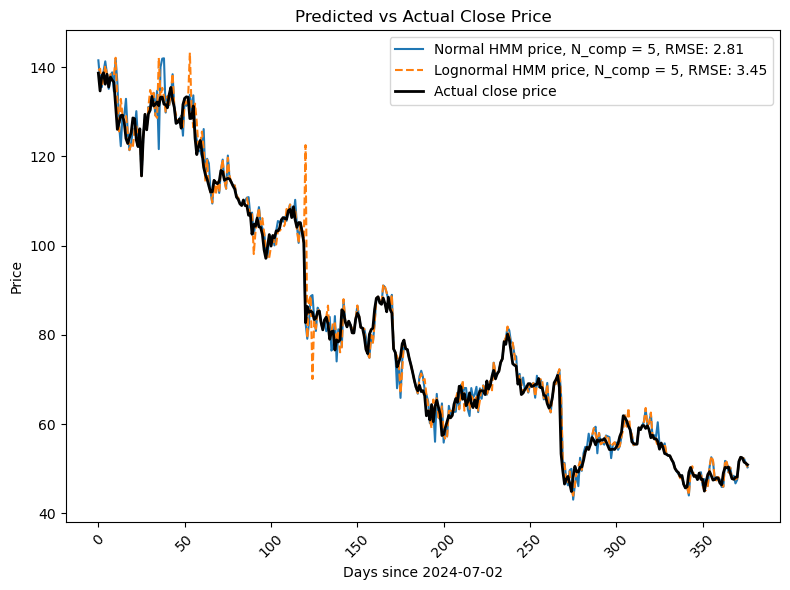

In [126]:
fig, ax = plt.subplots(figsize=(8, 6))
time_units = np.arange(len(log_price))
plt.plot(time_units, norm_price, label=f"Normal HMM price, N_comp = 5, RMSE: {rmse(norm_close, norm_price):.2f}")
plt.plot(time_units, log_price, label=f"Lognormal HMM price, N_comp = 5, RMSE: {rmse(log_close, log_price):.2f}", linestyle='--')
plt.plot(time_units, log_close, label="Actual close price", color='black', linewidth=2)
plt.xlabel("Days since " + start_date.strftime("%Y-%m-%d"))
plt.ylabel("Price")
plt.title("Predicted vs Actual Close Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Frequency')

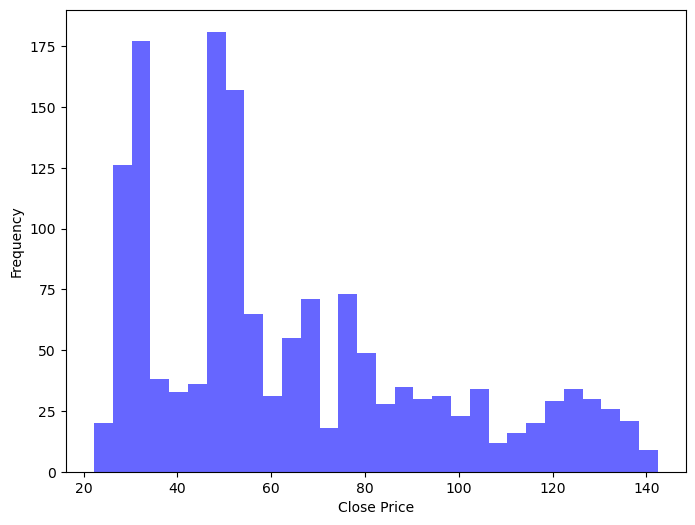

In [129]:
#Plot histogram of close prices: 
plt.figure(figsize=(8, 6))
plt.hist(obs['Close'], bins=30, alpha=0.6, color='blue')
plt.xlabel("Close Price")
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

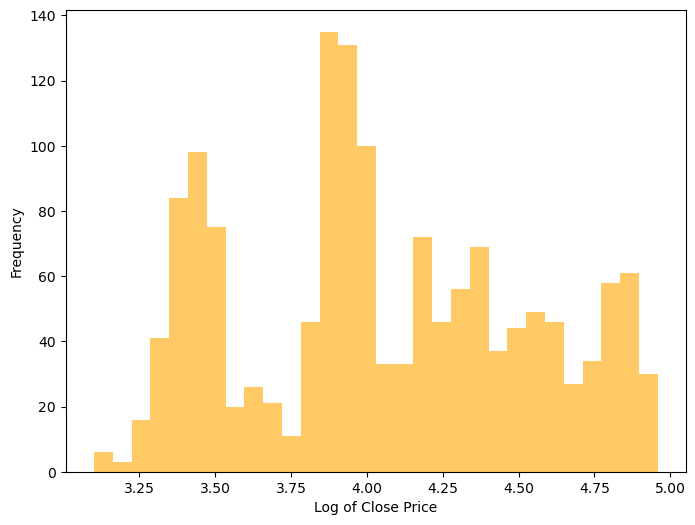

In [130]:
#plot log of close prices:  
plt.figure(figsize=(8, 6))
plt.hist(np.log(obs['Close']), bins=30, alpha=0.6, color='orange')
plt.xlabel("Log of Close Price")
plt.ylabel("Frequency")
